In [23]:
# 텐서플로 라이브러리 안에 있는 케라스 API에서 필요한 함수들을 불러옵니다.
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense, Input   

# 데이터를 다루는 데 필요한 라이브러리를 불러옵니다.
import numpy as np
import pandas as pd

In [38]:
df = pd.read_csv("pima-indians-diabetes3.csv")
print(df)

     pregnant  plasma  pressure  thickness  insulin   bmi  pedigree  age  \
0           6     148        72         35        0  33.6     0.627   50   
1           1      85        66         29        0  26.6     0.351   31   
2           8     183        64          0        0  23.3     0.672   32   
3           1      89        66         23       94  28.1     0.167   21   
4           0     137        40         35      168  43.1     2.288   33   
..        ...     ...       ...        ...      ...   ...       ...  ...   
763        10     101        76         48      180  32.9     0.171   63   
764         2     122        70         27        0  36.8     0.340   27   
765         5     121        72         23      112  26.2     0.245   30   
766         1     126        60          0        0  30.1     0.349   47   
767         1      93        70         31        0  30.4     0.315   23   

     diabetes  
0           1  
1           0  
2           1  
3           0  
4      

In [25]:
# | 컬럼                      | 의미            |
# | ------------------------ | --------------- |
# | Pregnancies              | 임신 횟수        |
# | Glucose                  | 혈당 수치         |
# | BloodPressure            | 혈압             |
# | SkinThickness            | 피부 두께         |
# | Insulin                  | 인슐린 수치       |
# | BMI                      | 체질량지수        |
# | DiabetesPedigreeFunction | 당뇨 유전 지수     |
# | Age                      | 나이              | 
# | Outcome                  | 당뇨병 여부(정답)  |

In [26]:
# 정상과 당뇨 환자가 각각 몇 명인지 조사

print(df["diabetes"].value_counts)

print(df.describe())

# plasma : 포도당 농도 = 혈당 수치

<bound method IndexOpsMixin.value_counts of 0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: diabetes, Length: 768, dtype: int64>
         pregnant      plasma    pressure   thickness     insulin         bmi  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.000000   99.000000  846.000000   67.100000   

         pedigree         age    diabetes  
count  768.000000  768.000000  768.00000

In [27]:
# 상관관계 확인
print(df.corr())

           pregnant    plasma  pressure  thickness   insulin       bmi  \
pregnant   1.000000  0.129459  0.141282  -0.081672 -0.073535  0.017683   
plasma     0.129459  1.000000  0.152590   0.057328  0.331357  0.221071   
pressure   0.141282  0.152590  1.000000   0.207371  0.088933  0.281805   
thickness -0.081672  0.057328  0.207371   1.000000  0.436783  0.392573   
insulin   -0.073535  0.331357  0.088933   0.436783  1.000000  0.197859   
bmi        0.017683  0.221071  0.281805   0.392573  0.197859  1.000000   
pedigree  -0.033523  0.137337  0.041265   0.183928  0.185071  0.140647   
age        0.544341  0.263514  0.239528  -0.113970 -0.042163  0.036242   
diabetes   0.221898  0.466581  0.065068   0.074752  0.130548  0.292695   

           pedigree       age  diabetes  
pregnant  -0.033523  0.544341  0.221898  
plasma     0.137337  0.263514  0.466581  
pressure   0.041265  0.239528  0.065068  
thickness  0.183928 -0.113970  0.074752  
insulin    0.185071 -0.042163  0.130548  
bmi    

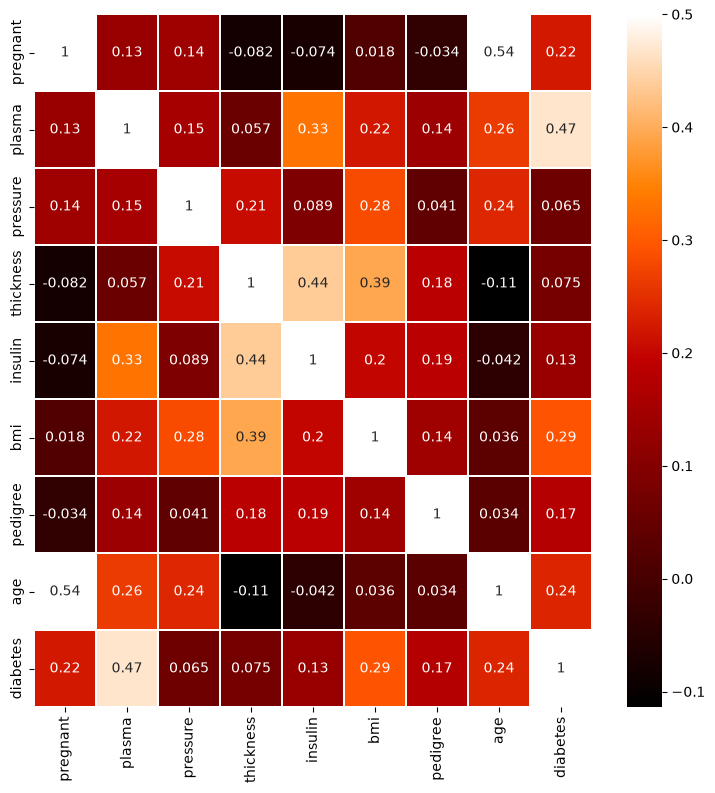

In [28]:
# 필요한 라이브러리를 불러옵니다.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 간의 상관 관계를 그래프로 표현해 봅니다.
colormap = plt.cm.gist_heat   #그래프의 색상 구성을 정합니다.
plt.figure(figsize=(9,9))   #그래프의 크기를 정합니다.

# 그래프의 속성을 결정합니다. vmax의 값을 0.5로 지정해 0.5에 가까울수록 밝은색으로 표시되게 합니다.
sns.heatmap(df.corr(),linewidths=0.1,vmax=0.5, cmap=colormap, linecolor='white', annot=True)
plt.show()

In [29]:
# 데이터 나누기

# 세부 정보를 X로 지정
x = df.iloc[ : , 0:8]
# [행, 열] 모양으로 : 은 처음부터 끝까지를 의미 => [ : , 0:8] 뜻은 행은 처음부터 끝까지, 열 (컬럼)은 0~7까지만

# 당뇨병 여부를 Y로 지정
y = df.iloc[ : ,  8]
# [ : ,  8]은 행은 처음부터 끝까지, 컬럼은 8번째꺼만

print(x)
print(y)

     pregnant  plasma  pressure  thickness  insulin   bmi  pedigree  age
0           6     148        72         35        0  33.6     0.627   50
1           1      85        66         29        0  26.6     0.351   31
2           8     183        64          0        0  23.3     0.672   32
3           1      89        66         23       94  28.1     0.167   21
4           0     137        40         35      168  43.1     2.288   33
..        ...     ...       ...        ...      ...   ...       ...  ...
763        10     101        76         48      180  32.9     0.171   63
764         2     122        70         27        0  36.8     0.340   27
765         5     121        72         23      112  26.2     0.245   30
766         1     126        60          0        0  30.1     0.349   47
767         1      93        70         31        0  30.4     0.315   23

[768 rows x 8 columns]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
N

In [30]:
# 학습용 / 테스트용 데이터 분리

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# 정상 : 980명
# 암환자 : 20명


# 정상 : 200명
# 암환자 : 0명
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # 같은 비율로 들어갈 수 있도록 분류모델에서는 stratify=y로 할 것
)               # 예를 들어 전체 데이터에서 위와 같이 980 : 20 이면 테스트 데이터도 저 비율로 나와야 함

# 정규화 
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [ ]:
# 모델링

# 데이터 크기 => 768 기준
# 천개 이하 : 1 ~ 2개
# 만개 이하 : 2 ~ 3개
# 10만개 이상 : 3 ~ 5개 까지 은닉층을 생성함
 
# 뉴런 갯수 
# 컬럼수 4~10 => 8 ~ 32
# 컬럼수 10~50개 =>	16~64개
# 컬럼수 50개 이상 => 32~256개

# 히든 레이어(은닉층) : 총 데이터 수 고려
# 뉴런 : 총 컬럼 수 고려

model = Sequential([
    Input(shape=(8,)),  # 총 컬럼수
    Dense(12,activation="relu"),
    Dense(8,activation="relu"),
    Dense(1,activation="sigmoid")
])

model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)
# 학습
model.fit(x,y,epochs=2000, verbose=1)


Epoch 1/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6510 - loss: 4.0418   
Epoch 2/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6510 - loss: 2.2818 
Epoch 3/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6484 - loss: 1.3175 
Epoch 4/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6016 - loss: 0.8318 
Epoch 5/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5612 - loss: 0.7180 
Epoch 6/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5846 - loss: 0.7057 
Epoch 7/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6042 - loss: 0.6922 
Epoch 8/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6094 - loss: 0.6832 
Epoch 9/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6380 - loss: 0.6658 
Epoch 10/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6484 - loss: 0.6554 
Epoch 11/2000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6276 - loss: 0.6497 
Epoch 12/2000
24/24 ━━━━━━━━━━━━━━━━━━━

In [69]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665 (2.60 KB)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 444 (1.74 KB)

In [70]:
# 콤파일 

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 학습
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=5,# 5개 학습하고 가중치 수정 => 데이터 5개 넣고 가중치 한번 수정
    validation_split=0.2,
    verbose=1
)

# 평가 
loss, acc = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print()
print("테스트 Loss :", round(loss, 4))
print("테스트 Accuracy :", round(acc, 4))

Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6456 - loss: 2.5572 - val_accuracy: 0.6423 - val_loss: 2.3445
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6375 - loss: 1.9517 - val_accuracy: 0.6504 - val_loss: 1.8775
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6456 - loss: 1.5802 - val_accuracy: 0.6423 - val_loss: 1.5060
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6415 - loss: 1.2792 - val_accuracy: 0.6748 - val_loss: 1.1901
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6477 - loss: 1.0399 - val_accuracy: 0.7236 - val_loss: 0.9589
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6578 - loss: 0.8958 - val_accuracy: 0.7154 - val_loss: 0.8378
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6497 - loss: 0.7903 - val_accuracy: 0.7236 - val_loss: 0.7446
Epoch 8/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6619 - loss: 0.7241 - val_accuracy: 0.7317 - v

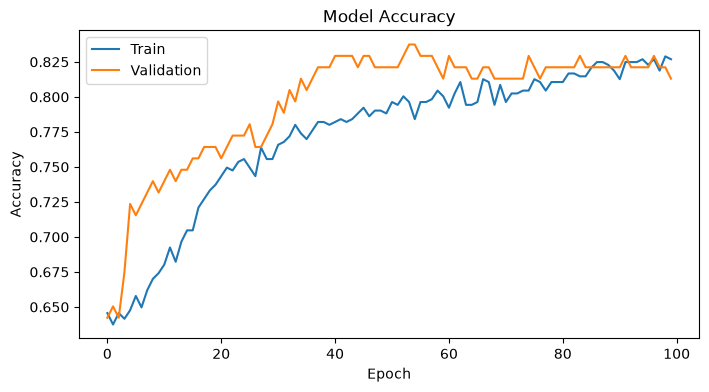

In [71]:
# 시각화
# 정확도
plt.figure(figsize=(8, 4))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

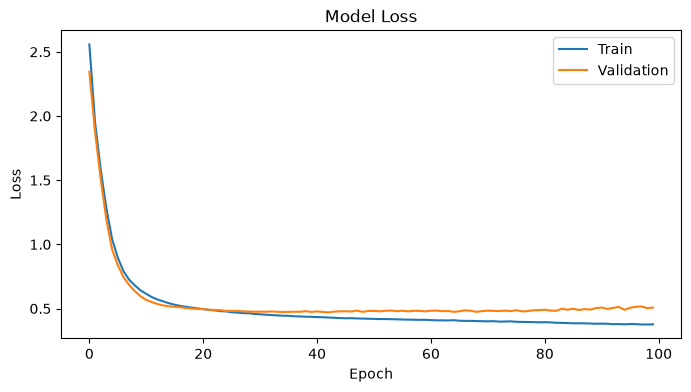

In [72]:
# Loss 그래프

plt.figure(figsize=(8, 4))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

# train 그래프가 계속 감소하는 양상인 이유는 데이터를 계속 학습을 하기 때문에 , vali 그래프는 어느순간 역전을 당하고 더 이상 내려가지 않음
# 만약 두 그래프의 차이가 점차 벌어지는 현상이 샐길 수도 있는데 그게 바로 과적합임
# 과적합을 피하려면 train 그래프는 내려가고 loss 그래프가 올라가는 시점에서 학습을 멈추거나 가중치를 변경해줘야 함 

In [73]:
# 예측

pred = model.predict(x_test)
print(pred)

# 새로운 환자 예측

new_patient = np.array([
    [2, 120, 70, 20, 85, 25.0, 0.3, 35]
])

new_patient = scaler.transform(new_patient)

result = model.predict(new_patient)

print()
print("당뇨병 확률 :", round(result[0][0] * 100, 2), "%")

if result[0][0] >= 0.5:
    print("예측 : 당뇨병")
else:
    print("예측 : 정상")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[6.4020693e-01]
 [2.3240605e-01]
 [1.8001175e-01]
 [1.5854287e-01]
 [1.0804916e-03]
 [3.3620214e-01]
 [3.5343909e-01]
 [9.2638189e-01]
 [2.1117841e-05]
 [8.9621931e-01]
 [2.8324592e-01]
 [8.2097161e-01]
 [9.8553352e-02]
 [8.4001169e-02]
 [2.4975665e-01]
 [3.7473875e-01]
 [4.8900867e-01]
 [1.0804916e-03]
 [9.1863275e-01]
 [4.8424229e-01]
 [4.1434178e-01]
 [9.9213666e-01]
 [2.1412063e-01]
 [9.1467571e-01]
 [3.9327136e-01]
 [7.0152150e-06]
 [7.2305202e-01]
 [1.0804916e-03]
 [2.4295513e-01]
 [1.0804916e-03]
 [1.7619727e-03]
 [1.3758914e-04]
 [5.2321601e-01]
 [8.8183552e-01]
 [9.3517864e-01]
 [2.3300858e-01]
 [2.6230770e-01]
 [2.2917215e-05]
 [8.7912858e-01]
 [5.4635173e-01]
 [4.8498228e-01]
 [3.3670923e-01]
 [2.5020105e-01]
 [3.2604152e-01]
 [2.9883048e-01]
 [4.2436472e-01]
 [1.8031581e-01]
 [6.4659426e-03]
 [6.2411034e-01]
 [3.7325656e-01]
 [4.7473070e-01]
 [9.4998485e-01]
 [4.7817478e-01]
 [1.1047990e-01]
 [5.8927524e-01]
 [5.9215093e-01]
 [8.734291

c:\miniconda3\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
